In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import pandas as pd
import json
import numpy as np
import joblib

from modelos_utils import *

c:\Users\tatic\OneDrive\Escritorio\PROYECTO DE DATOS\c2526-R1\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [5]:
config = {
    "tfidf_titulo_max_features": 2000,
    "tfidf_descripcion_max_features": 4000,
    "tfidf_tags_max_features": 2000,
    "tfidf_subtitulos_max_features": 5000,
    "ngram_range": (1,2),
    "alpha_values": [0.1, 0.5, 1.0, 2.0],
    "cv_folds": 5
}

preprocess = ColumnTransformer(
    transformers=[
        ("Titulo", TfidfVectorizer(max_features=config["tfidf_titulo_max_features"], ngram_range=config["ngram_range"], stop_words='english'), "Titulo"),
        ("Descripcion", TfidfVectorizer(max_features=config["tfidf_descripcion_max_features"], ngram_range=config["ngram_range"], stop_words='english'), "Descripcion"),
        ("Tags",TfidfVectorizer(max_features=config["tfidf_tags_max_features"], ngram_range=config["ngram_range"]),"Tags"),

        ("Subtitulos", TfidfVectorizer(max_features=config["tfidf_subtitulos_max_features"], ngram_range=config["ngram_range"]), "Subtitulos"), ("Generos", OneHotEncoder(), ["Generos"])
    ]
)

In [7]:
from modelos_utils import *

def download_model_dfs():
    with open("Private/claves.json", "r", encoding="utf-8") as archivo:
        claves = json.load(archivo)
        df_train = download_dataframe_minio("pd1", "grupo1/modelos/train_filtered", claves, "parquet")
        df_validation = download_dataframe_minio("pd1", "grupo1/modelos/validation_filtered", claves, "parquet")
        df_test = download_dataframe_minio("pd1", "grupo1/modelos/test_filtered", claves, "parquet")

        df_train['Duracion'] = df_train['Duracion'].apply(iso_a_minutos)
        df_validation['Duracion'] = df_validation['Duracion'].apply(iso_a_minutos)
        df_test['Duracion'] = df_test['Duracion'].apply(iso_a_minutos)

        return df_train, df_validation, df_test
df_train, df_validation, df_test = download_model_dfs()
df_train = pd.concat([df_train, df_validation])

In [8]:
X_train = df_train.drop(columns=["Rango_edad"])
y_train = df_train["Rango_edad"] != 'Adult'

X_test = df_test.drop(columns=["Rango_edad"])
y_test = df_test["Rango_edad"] != 'Adult'

In [9]:
best_alpha = None
best_recall = 0

results = []

In [11]:
for alpha in config["alpha_values"]:

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", MultinomialNB(alpha=alpha))
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=config["cv_folds"],
        scoring="recall",
        n_jobs=1
    )

    mean_recall = scores.mean()

    print(f"Alpha {alpha} -> Recall CV: {mean_recall}")

    results.append((alpha, mean_recall))

    if mean_recall > best_recall:
        best_recall = mean_recall
        best_alpha = alpha


print("\nMejor alpha:", best_alpha)

Alpha 0.1 -> Recall CV: 0.9172533416823839
Alpha 0.5 -> Recall CV: 0.9153901190708023
Alpha 1.0 -> Recall CV: 0.9142043243634836
Alpha 2.0 -> Recall CV: 0.9134421507269017

Mejor alpha: 0.1


In [12]:
best_model = Pipeline([
    ("preprocess", preprocess),
    ("model", MultinomialNB(alpha=best_alpha))
])

best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Titulo', ...), ('Descripcion', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [16]:
pred_test = best_model.predict(X_test)

test_recall = recall_score(y_test, pred_test)

print("\nResultados en test:")
print("Recall:", test_recall)

print("\nClassification Report:")
print(classification_report(y_test, pred_test))


Resultados en test:
Recall: 0.9093525179856116

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.95      0.93      2090
        True       0.95      0.91      0.93      2085

    accuracy                           0.93      4175
   macro avg       0.93      0.93      0.93      4175
weighted avg       0.93      0.93      0.93      4175



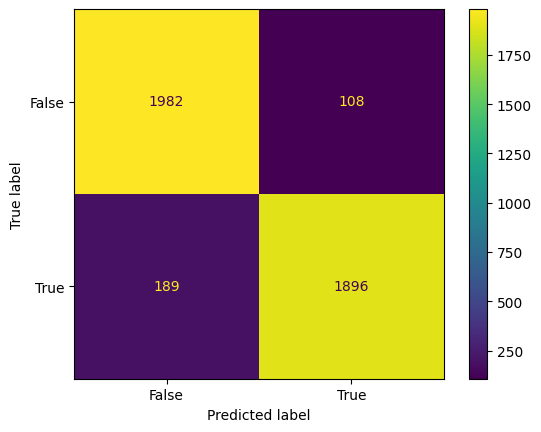

In [14]:
cm = confusion_matrix(y_test, pred_test, labels=best_model["model"].classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model["model"].classes_
)

disp.plot()
plt.show()

In [15]:
joblib.dump(best_model, "naive_bayes_kids_model.joblib")

['naive_bayes_kids_model.joblib']